Accuracy: 80.83333333333333
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      1.00      1.00         2
           2       0.33      0.67      0.44         3
           3       1.00      0.00      0.00         5
           4       1.00      0.50      0.67         4
           5       1.00      1.00      1.00         2
           7       1.00      0.75      0.86         4
           8       1.00      0.67      0.80         3
           9       1.00      0.75      0.86         4
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         1
          12       0.40      1.00      0.57         4
          13       1.00      0.80      0.89         5
          14       1.00      0.40      0.57         5
          15       0.67      1.00      0.80         2
          16       1.00      0.67      0.80         3
          17       1.00      1.00      1.00         3

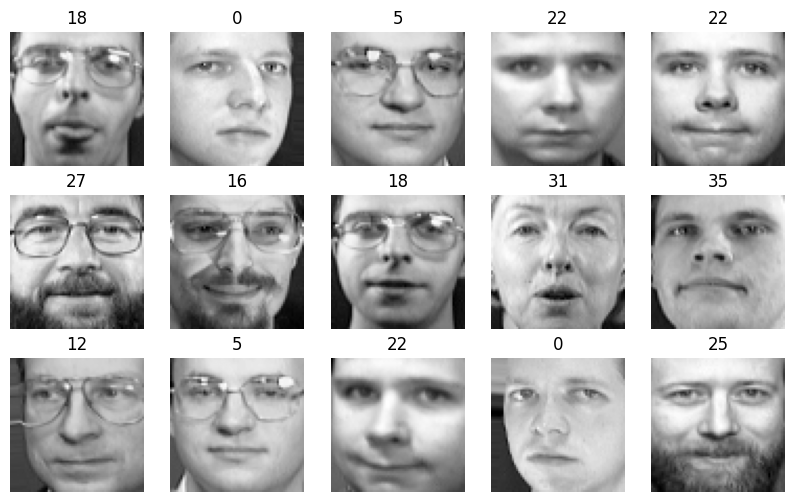

In [6]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

data = fetch_olivetti_faces(shuffle=True, random_state=42)
X_train,X_test,y_train,y_test = train_test_split(
    data.data,data.target,test_size=0.3,random_state=42)

model = GaussianNB().fit(X_train,y_train)
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test,pred)*100)
print(classification_report(y_test,pred,zero_division=1))
print(confusion_matrix(y_test,pred))
print("CV Accuracy:", cross_val_score(model,data.data,data.target,cv=5).mean()*100)

fig,ax = plt.subplots(3,5,figsize=(10,6))
for i,a in enumerate(ax.ravel()):
    a.imshow(X_test[i].reshape(64,64), cmap='gray')
    a.set_title(pred[i]); a.axis('off')
plt.show()
